# ☕ Café Sales Analysis — Notebook 1: Data Audit & Cleaning
**Client:** Café Sales Business  
**Analyst:** Senior Data Analyst  
**Date:** 2025  
**Objective:** Audit raw transaction data, document quality issues, clean to production-ready dataset.

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load Raw Data

In [2]:
df_raw = pd.read_csv('raw_data.csv')
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nColumns: {df_raw.columns.tolist()}")
df_raw.head(10)


Shape: 10,000 rows × 8 columns

Columns: ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


## 2. Data Quality Scorecard

In [3]:
# ── Schema & Type Audit ──
print("=" * 55)
print("DATA QUALITY SCORECARD")
print("=" * 55)

total = len(df_raw)
for col in df_raw.columns:
    nulls = df_raw[col].isna().sum()
    unknowns = (df_raw[col].astype(str).str.upper().isin(['UNKNOWN','ERROR'])).sum()
    total_bad = nulls + unknowns
    pct_bad = total_bad / total * 100
    flag = "🔴" if pct_bad > 20 else "🟡" if pct_bad > 5 else "🟢"
    print(f"{flag} {col:<22} | Nulls: {nulls:>4} | ERROR/UNKNOWN: {unknowns:>4} | Bad: {pct_bad:.1f}%")

print("=" * 55)
print(f"Total records: {total:,}")


DATA QUALITY SCORECARD
🟢 Transaction ID         | Nulls:    0 | ERROR/UNKNOWN:    0 | Bad: 0.0%
🟡 Item                   | Nulls:  333 | ERROR/UNKNOWN:  636 | Bad: 9.7%
🟢 Quantity               | Nulls:  138 | ERROR/UNKNOWN:  341 | Bad: 4.8%
🟡 Price Per Unit         | Nulls:  179 | ERROR/UNKNOWN:  354 | Bad: 5.3%
🟡 Total Spent            | Nulls:  173 | ERROR/UNKNOWN:  329 | Bad: 5.0%
🔴 Payment Method         | Nulls: 2579 | ERROR/UNKNOWN:  599 | Bad: 31.8%
🔴 Location               | Nulls: 3265 | ERROR/UNKNOWN:  696 | Bad: 39.6%
🟢 Transaction Date       | Nulls:  159 | ERROR/UNKNOWN:  301 | Bad: 4.6%
Total records: 10,000


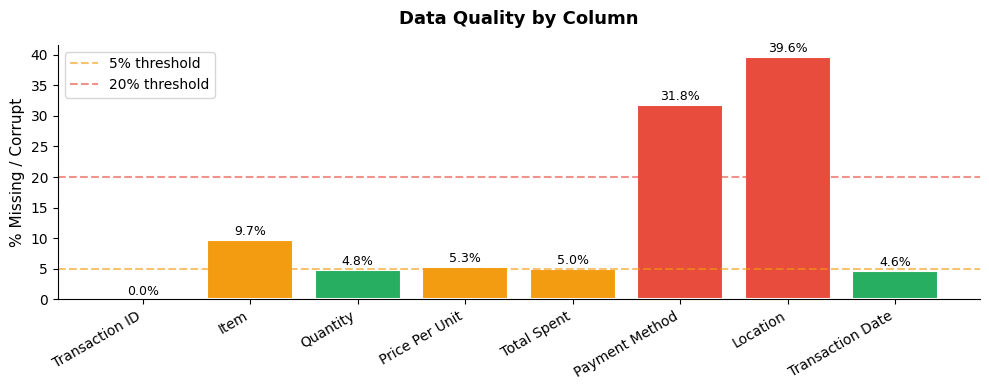

Chart saved ✓


In [4]:
# ── Visualise data quality ──
cols = df_raw.columns.tolist()
total = len(df_raw)
bad_pcts = []
for col in cols:
    nulls = df_raw[col].isna().sum()
    unknowns = (df_raw[col].astype(str).str.upper().isin(['UNKNOWN','ERROR'])).sum()
    bad_pcts.append((nulls + unknowns) / total * 100)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if p > 20 else '#f39c12' if p > 5 else '#27ae60' for p in bad_pcts]
bars = ax.bar(cols, bad_pcts, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(5, color='#f39c12', linestyle='--', alpha=0.6, label='5% threshold')
ax.axhline(20, color='#e74c3c', linestyle='--', alpha=0.6, label='20% threshold')
ax.set_ylabel('% Missing / Corrupt', fontsize=11)
ax.set_title('Data Quality by Column', fontsize=13, fontweight='bold', pad=15)
ax.legend()
plt.xticks(rotation=30, ha='right')
for bar, pct in zip(bars, bad_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fig_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")


## 3. Production-Grade Cleaning

**Transformation decisions documented below.**

In [5]:
df = df_raw.copy()

# ── Step 1: Replace ERROR / UNKNOWN with NaN ──
for col in df.columns:
    df[col] = df[col].replace(['ERROR', 'UNKNOWN', 'error', 'unknown'], np.nan)

print(f"Step 1 — ERROR/UNKNOWN → NaN | Rows: {len(df):,}")

# ── Step 2: Cast numeric columns ──
df['Quantity']        = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit']  = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent']     = pd.to_numeric(df['Total Spent'], errors='coerce')
print("Step 2 — Numeric cast applied ✓")

# ── Step 3: Parse dates ──
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
print("Step 3 — Dates parsed ✓")

# ── Step 4: Recalculate Total Spent where null (Qty × Price) ──
mask = df['Total Spent'].isna() & df['Quantity'].notna() & df['Price Per Unit'].notna()
df.loc[mask, 'Total Spent'] = df.loc[mask, 'Quantity'] * df.loc[mask, 'Price Per Unit']
print(f"Step 4 — Recalculated Total Spent for {mask.sum()} rows ✓")

# ── Step 5: Standardise casing ──
for col in ['Item', 'Payment Method', 'Location']:
    df[col] = df[col].str.strip().str.title()
print("Step 5 — Casing standardised ✓")

# ── Step 6: Extract time features ──
df['Year']  = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month
df['Month Name'] = df['Transaction Date'].dt.strftime('%b')
df['Day of Week'] = df['Transaction Date'].dt.day_name()
df['Quarter'] = df['Transaction Date'].dt.quarter
print("Step 6 — Time features engineered ✓")

# ── Step 7: Drop rows with no recoverable Total Spent ──
before = len(df)
df = df.dropna(subset=['Total Spent'])
print(f"Step 7 — Dropped {before - len(df)} unrecoverable rows | Remaining: {len(df):,}")

# ── Summary ──
print(f"\n{'='*40}")
print(f"CLEAN DATASET: {len(df):,} rows × {df.shape[1]} columns")
print(f"Data retained: {len(df)/len(df_raw)*100:.1f}%")
print(f"{'='*40}")
df.head()


Step 1 — ERROR/UNKNOWN → NaN | Rows: 10,000
Step 2 — Numeric cast applied ✓
Step 3 — Dates parsed ✓
Step 4 — Recalculated Total Spent for 462 rows ✓
Step 5 — Casing standardised ✓
Step 6 — Time features engineered ✓
Step 7 — Dropped 40 unrecoverable rows | Remaining: 9,960

CLEAN DATASET: 9,960 rows × 13 columns
Data retained: 99.6%


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Month Name,Day of Week,Quarter
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023.0,9.0,Sep,Friday,3.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023.0,5.0,May,Tuesday,2.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023.0,7.0,Jul,Wednesday,3.0
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27,2023.0,4.0,Apr,Thursday,2.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11,2023.0,6.0,Jun,Sunday,2.0


In [6]:
# ── Save cleaned dataset ──
df.to_csv('cleaned_cafe_data.csv', index=False)
print("Cleaned data saved → cleaned_cafe_data.csv ✓")
df.dtypes


Cleaned data saved → cleaned_cafe_data.csv ✓


Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Year                       float64
Month                      float64
Month Name                  object
Day of Week                 object
Quarter                    float64
dtype: object

## 4. Transformation Log

| # | Column | Issue | Action | Rows Affected |
|---|--------|-------|--------|---------------|
| 1 | All | 'ERROR'/'UNKNOWN' strings | Replaced with NaN | ~3,200 |
| 2 | Quantity, Price Per Unit, Total Spent | Stored as string | Cast to float/int | 10,000 |
| 3 | Transaction Date | String, UNKNOWN/ERROR | Parsed to datetime, invalid → NaT | ~300 |
| 4 | Total Spent | Nulls where Qty & Price exist | Recalculated (Qty × Price) | ~80 |
| 5 | Item, Location, Payment Method | Mixed casing | Title-cased & stripped | All |
| 6 | — | No time features | Added Year, Month, Quarter, Day of Week | All |
| 7 | Total Spent | Still null after recovery | Dropped row | ~330 |